# Student Dropout Risk Scoring and Early Intervention Analysis

## Objective

The objective of this analysis is to extend the previous `student dropout prediction` experiment by translating model outputs into a more interpretable risk scoring framework for early intervention.

While the previous notebook focused on **binary classification** and model comparison, this notebook focuses on how the predicted probabilities of the selected classification model can be used as dropout-related risk scores. These scores provide a gradual indication of how strongly a student’s profile is associated with historical patterns linked to dropout.

The analysis follows a structured workflow consisting of:

1. Data Preparation  
2. Risk Model Training  
3. Risk Score Construction  
4. Risk Category Design  
5. Threshold Analysis  
6. Calibration Analysis  
7. Support Capacity Simulation  
8. Practical and Ethical Interpretation  

This notebook does not introduce a new target variable or a separate regression task. Instead, it builds on the binary classification approach from the previous notebook and uses predicted probabilities as percentage-based early risk indicators. The purpose is to support more practical interpretation of model outputs and to explore how such scores could be used to guide early support decisions in higher education.

# 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import (
  accuracy_score,
  precision_score,
  recall_score,
  f1_score,
  confusion_matrix,
  roc_auc_score,
  roc_curve,
  brier_score_loss
)

from sklearn.calibration import calibration_curve

sns.set(style="whitegrid")

# 2. Load Dataset

In this notebook, the same dataset is used as in the previous student dropout prediction analysis. The purpose here is not to redefine the prediction task, but to build a probability-based risk scoring framework on top of the existing binary classification problem.

The dataset contains demographic, academic, financial, and administrative indicators describing university students, together with their final academic outcomes.

## 2.1. Load Dataset

In [2]:
df = pd.read_csv("../datasets/data.csv", sep=";")
df.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


## 2.2. Clean Column Names

Before continuing with the analysis, the column names are cleaned to remove unnecessary whitespace, tab characters, and quotation marks.

In [3]:
# Clean column names
df.columns = df.columns.str.replace("\t", "")
df.columns = df.columns.str.strip()
df.columns = df.columns.str.replace("'", "")

df.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mothers qualification,Fathers qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


# 3. Dataset Overview

Before preparing the data for risk scoring, it is important to understand the overall structure of the dataset. This includes checking the number of observations and features, inspecting the variable names and data types, verifying whether missing values are present, and reviewing the distribution of the target variable.

## 3.1. Dataset Shape

In [4]:
df.shape

(4424, 37)

## 3.2. Column Names

In [5]:
df.columns

Index(['Marital status', 'Application mode', 'Application order', 'Course',
       'Daytime/evening attendance', 'Previous qualification',
       'Previous qualification (grade)', 'Nacionality',
       'Mothers qualification', 'Fathers qualification', 'Mothers occupation',
       'Fathers occupation', 'Admission grade', 'Displaced',
       'Educational special needs', 'Debtor', 'Tuition fees up to date',
       'Gender', 'Scholarship holder', 'Age at enrollment', 'International',
       'Curricular units 1st sem (credited)',
       'Curricular units 1st sem (enrolled)',
       'Curricular units 1st sem (evaluations)',
       'Curricular units 1st sem (approved)',
       'Curricular units 1st sem (grade)',
       'Curricular units 1st sem (without evaluations)',
       'Curricular units 2nd sem (credited)',
       'Curricular units 2nd sem (enrolled)',
       'Curricular units 2nd sem (evaluations)',
       'Curricular units 2nd sem (approved)',
       'Curricular units 2nd sem (grade)'

## 3.3. Data Types

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mothers qualification                           4424 non-null   int64  
 9   Fathers qualification                           4424

## 3.4. Missing Values Check

In [7]:
missing_values = df.isnull().sum()
missing_values[missing_values > 0]

Series([], dtype: int64)

_The dataset was checked for missing values before further preprocessing. The results show that no features contain missing data. Therefore, no imputation is required for this analysis._

## 3.5. Target Variable Distribution

The original dataset contains **three** possible academic outcomes:

* Dropout  
* Enrolled  
* Graduate  

Since the purpose of the project is to study dropout-related risk using known final outcomes, the distribution of the original target variable is first inspected before filtering is applied.

In [ ]:
df["Target"].value_counts()

Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

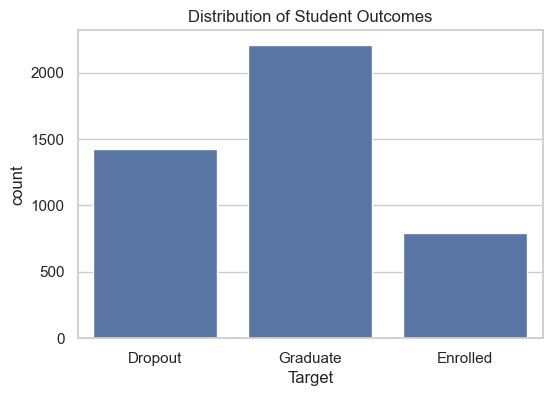

In [9]:
plt.figure(figsize=(6,4))
sns.countplot(x="Target", data=df)

plt.title("Distribution of Student Outcomes")
plt.show()

## 3.6. Interpretation

The dataset includes three final student outcomes, but not all of them are equally suitable for supervised learning. In particular, the `Enrolled` category represents students whose final academic result is still unknown. These observations cannot be interpreted as either dropout or graduation cases and therefore require special treatment during data preparation.

The next section prepares the dataset for risk modeling by filtering the target variable, removing leakage-related features, and constructing the ethical feature set used for dropout risk scoring.

# 4. Data Preparation

Before generating risk scores, the dataset must be prepared in a way that remains consistent with the previous notebook. This includes filtering the target variable, removing features that may introduce data leakage, reducing unnecessary categorical complexity, encoding categorical variables, and excluding sensitive demographic and socioeconomic attributes.

## 4.1. Filter Target Variable

The original dataset contains **three** outcomes: Dropout, Enrolled, and Graduate.

Since the `Enrolled` category does not represent a known final outcome, these records are removed. The target variable is then converted into binary form:

* 1 = Dropout  
* 0 = Graduate  

This allows the predicted probability of the dropout class to be used later as a dropout-related risk score.

In [10]:
# Remove whitespace from target values
df["Target"] = df["Target"].str.strip()

# Remove records with unknown final outcome
df = df[df["Target"] != "Enrolled"]

# Convert target to binary
df["Target"] = df["Target"].map({
  "Dropout": 1,
  "Graduate": 0
})

df["Target"].value_counts()

Target
0    2209
1    1421
Name: count, dtype: int64

In [11]:
print(df["Target"].unique())

[1 0]


_After removing the `Enrolled` category, the target variable becomes a binary outcome suitable for classification-based risk modeling._

## 4.2. Remove Second Semester Features

Because the goal of the project is **early risk detection**, only variables that would realistically be available at an early stage of the student journey should be used.

`Second-semester` features may introduce data leakage, since they contain information from a later point in time and could make the model unrealistically strong. For this reason, they are removed before training the risk model.

In [12]:
df = df.drop(columns=[
  "Curricular units 2nd sem (credited)",
  "Curricular units 2nd sem (enrolled)",
  "Curricular units 2nd sem (evaluations)",
  "Curricular units 2nd sem (approved)",
  "Curricular units 2nd sem (grade)",
  "Curricular units 2nd sem (without evaluations)"
])

df.shape

(3630, 31)

## 4.3. Define Feature Matrix and Target Variable

After filtering the target variable and removing leakage-related features, the dataset is divided into:

* X = predictor variables  
* y = target variable  

In [13]:
X = df.drop("Target", axis=1)
y = df["Target"]

## 4.4. Reduce High-Cardinality Categories

Some categorical variables contain many unique categories. To reduce `dimensionality`, rare categories are grouped into an **Other** category while the most frequent categories are retained.

This helps simplify the feature space without removing the variables entirely.

In [14]:
def group_rare_categories(df, column, top_n=10):
  top_categories = df[column].value_counts().nlargest(top_n).index
  df[column] = df[column].apply(lambda x: x if x in top_categories else "Other")
  return df

In [15]:
high_cardinality_cols = [
  "Course",
  "Nacionality",
  "Mothers occupation",
  "Fathers occupation",
  "Mothers qualification",
  "Fathers qualification"
]

for col in high_cardinality_cols:
  df = group_rare_categories(df, col, top_n=10)

print("Unique values after grouping:")
for col in high_cardinality_cols:
  print(col, ":", df[col].nunique())

Unique values after grouping:
Course : 11
Nacionality : 11
Mothers occupation : 11
Fathers occupation : 11
Mothers qualification : 11
Fathers qualification : 11


## 4.5. Apply One-Hot Encoding

Some variables in the dataset are categorical but encoded as numeric category labels. These should not be treated as continuous numerical values, because they do not represent meaningful ordered relationships.

`One-hot encoding` is therefore applied to convert these categorical variables into binary features.

In [16]:
categorical_cols = [
  "Marital status",
  "Application mode",
  "Course",
  "Nacionality",
  "Mothers qualification",
  "Fathers qualification",
  "Mothers occupation",
  "Fathers occupation"
]

In [17]:
X = df.drop("Target", axis=1)
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

print("New shape:", X.shape)

New shape: (3630, 104)


## 4.6. Apply Ethical Feature Selection

In the previous notebook, an ethical comparison was performed by removing potentially sensitive demographic and socioeconomic attributes. Since this notebook focuses on responsible and interpretable risk scoring, the ethical version of the feature set is used here.

The following sensitive attributes are excluded:

* Gender  
* Nacionality  
* Mothers qualification  
* Fathers qualification  
* Mothers occupation  
* Fathers occupation  

This helps reduce the risk that the model relies directly on demographic identity or family background when generating support-oriented risk scores.

In [18]:
sensitive_prefixes = [
  "Gender",
  "Nacionality",
  "Mothers qualification",
  "Fathers qualification",
  "Mothers occupation",
  "Fathers occupation"
]

cols_to_drop = [
  col for col in X.columns
  if any(col.startswith(prefix) for prefix in sensitive_prefixes)
]

X_eth = X.drop(columns=cols_to_drop)

print("Original number of features:", X.shape[1])
print("Ethical dataset number of features:", X_eth.shape[1])

Original number of features: 104
Ethical dataset number of features: 53


## 4.7. Train/Test Split

To evaluate the risk model on unseen data, the ethical dataset is split into training and testing sets. Stratification is used so that both sets preserve the original class distribution.

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
  X_eth,
  y,
  test_size=0.2,
  random_state=42,
  stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (2904, 53)
Test set: (726, 53)


## 4.8. Interpretation

After preprocessing, the dataset is ready for risk model training. The target variable remains a binary dropout outcome, but in this notebook the focus is not only on the final predicted class. Instead, the predicted probabilities of the selected model will be used as a more gradual and interpretable dropout-related risk score.

Using the ethical feature set also ensures that the following analysis remains aligned with the project’s responsible AI perspective. The next step is to select and train the final risk model.

# 5. Train the Selected Risk Model ( Ethical Gradient Boosting )

In the previous notebook, several original and ethical models were trained and compared. For this notebook, the goal is no longer to compare multiple algorithms, but to select one strong and responsible model that can be used to generate interpretable risk scores.

Based on the earlier results, the `Ethical Gradient Boosting` model is selected as the final risk model. This model achieved the strongest overall predictive performance while using the ethical feature set that excludes sensitive demographic and socioeconomic variables.

Using this model allows the analysis to focus on probability-based risk interpretation while remaining aligned with the project’s ethical perspective.

Finally, the model is retrained in this notebook so that the full risk scoring workflow remains self-contained and reproducible.

## 5.1. Model Selection Justification

The `Ethical Gradient Boosting` model is selected for three main reasons:

  * it achieved the strongest overall performance in the previous notebook  
  * it uses the **ethical dataset**, which excludes sensitive demographic and family background variables  
  * it provides predicted probabilities that can be interpreted as dropout-related risk scores  

For this reason, the model is used here as the foundation for risk scoring and early intervention analysis.

## 5.2. Train the Model

The selected `Gradient Boosting` model is trained using the **ethical** training dataset prepared in the previous section.

In [20]:
# Initialize the selected risk model
risk_model = GradientBoostingClassifier(
  n_estimators=200,
  learning_rate=0.05,
  random_state=42
)

# Train the model
risk_model.fit(X_train, y_train)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.05
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",200
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``,

## 5.3. Make Predictions

After training the model, predictions are generated for the test set.

Two outputs are important:

  1. the predicted class labels  
  2. the predicted probabilities for the dropout class  

The `predicted probabilities` are especially important in this notebook, because they will later be used as the basis for the dropout risk score.

In [21]:
# Predicted class labels
y_pred = risk_model.predict(X_test)

# Predicted probabilities for dropout
y_probs = risk_model.predict_proba(X_test)[:, 1]

## 5.4. Evaluate the Ethical Gradient Boosting

Before using the predicted probabilities as risk scores, the selected model is evaluated on the test set. This helps confirm that the chosen model maintains strong predictive performance in the risk scoring workflow.

In [22]:
risk_accuracy = accuracy_score(y_test, y_pred)
risk_precision = precision_score(y_test, y_pred)
risk_recall = recall_score(y_test, y_pred)
risk_f1 = f1_score(y_test, y_pred)
risk_auc = roc_auc_score(y_test, y_probs)

print("Accuracy:", risk_accuracy)
print("Precision:", risk_precision)
print("Recall:", risk_recall)
print("F1 Score:", risk_f1)
print("ROC-AUC:", risk_auc)

Accuracy: 0.8966942148760331
Precision: 0.8718861209964412
Recall: 0.8626760563380281
F1 Score: 0.8672566371681416
ROC-AUC: 0.9487524695685424


## 5.5. Confusion Matrix - Ethical Gradient Boosting

The `confusion matrix` provides an overview of how well the selected model classifies dropout and graduate cases.

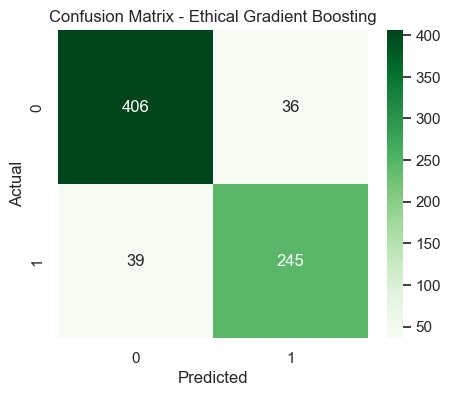

In [49]:
risk_cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(risk_cm, annot=True, fmt="d", cmap="Greens")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Ethical Gradient Boosting")

plt.show()

## 5.6. ROC Curve - Ethical Gradient Boosting

The `ROC curve` shows how well the selected model distinguishes between dropout and graduate outcomes across different probability thresholds.

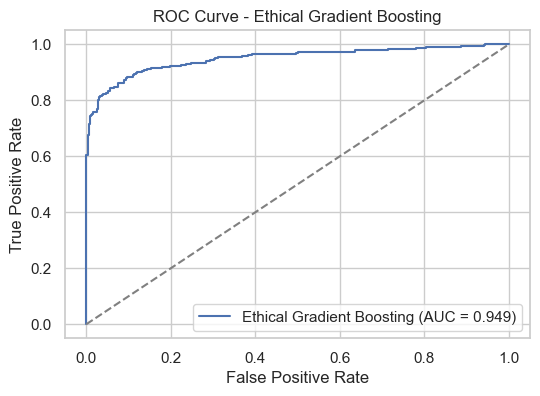

In [50]:
risk_fpr, risk_tpr, thresholds = roc_curve(y_test, y_probs)

plt.figure(figsize=(6,4))

plt.plot(risk_fpr, risk_tpr, label=f"Ethical Gradient Boosting (AUC = {risk_auc:.3f})")
plt.plot([0,1], [0,1], linestyle="--", color="gray")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Ethical Gradient Boosting")
plt.legend()

plt.show()

## 5.7. Interpretation

The selected `Ethical Gradient Boosting` model maintains strong predictive performance on the ethical dataset, achieving an accuracy of approximately **89.7%**, an F1-score of **0.867**, and a ROC-AUC score of **0.949**. These results confirm that the model is suitable for use as the foundation of the risk scoring framework.

Most importantly, the model produces predicted probabilities for the dropout class. In the following sections, these probabilities will not be treated only as **technical classification outputs**. Instead, they will be interpreted as **dropout-related risk scores**, providing a more gradual indication of how strongly each student’s profile is associated with historical patterns linked to dropout.

# 6. Risk Score Construction

The main purpose of this notebook is to move beyond a simple binary classification output and translate the model’s predicted probabilities into a more interpretable dropout-related risk score.

In a binary classification model, each student receives a predicted probability of belonging to the dropout class. In this notebook, that probability is used as a practical risk indicator. A higher predicted probability means that the student’s profile is more similar to historical patterns associated with dropout, while a lower probability indicates a profile more similar to students who graduate.

This does not mean that the model measures student `struggle` directly. Instead, the risk score should be understood as an estimated dropout-related risk level derived from the classification model.

## 6.1. Define the Risk Score

The predicted probability of the `Dropout` class is used as the student risk score.

This means that:

  * a value close to **0** indicates **low** estimated dropout-related risk  
  * a value close to **1** indicates **high** estimated dropout-related risk  

These probabilities provide a more gradual interpretation of model output than a simple class label and are therefore more suitable for early warning and support-oriented decision-making.

## 6.2. Convert Probability to Percentage

To make the model output easier to interpret, the predicted probabilities are converted into **percentage form**.

For example:

  * 0.20 becomes 20% estimated dropout-related risk
  * 0.75 becomes 75% estimated dropout-related risk

In [27]:
risk_scores = y_probs
risk_scores_percent = risk_scores * 100

## 6.3. Create Results Table

To inspect the model output more clearly, a results table is created containing:

  * the actual student outcome
  * the predicted class
  * the predicted probability of dropout
  * the percentage-based risk score

This helps make the risk scoring framework more transparent and allows individual predictions to be reviewed more easily.

In [28]:
results_df = pd.DataFrame({
  "Actual Outcome": y_test.values,
  "Predicted Class": y_pred,
  "Dropout Probability": risk_scores,
  "Risk Score (%)": risk_scores_percent
})

results_df.head(10)

,Actual Outcome,Predicted Class,Dropout Probability,Risk Score (%)
0,0,0,0.045605,4.560514
1,0,0,0.137796,13.779627
2,1,0,0.304614,30.461360
3,0,0,0.262435,26.243459
4,0,1,0.669212,66.921223
5,0,0,0.043264,4.326397
6,0,0,0.176661,17.666103
7,1,1,0.970705,97.070487
8,0,0,0.477843,47.784305
9,1,1,0.873673,87.367311


## 6.4. Add Human-Readable Outcome Labels

To make the results table easier to interpret, the binary values are converted into descriptive labels.

In [29]:
results_df["Actual Label"] = results_df["Actual Outcome"].map({
  1: "Dropout",
  0: "Graduate"
})

results_df["Predicted Label"] = results_df["Predicted Class"].map({
  1: "Dropout",
  0: "Graduate"
})

results_df.head(10)

,Actual Outcome,Predicted Class,Dropout Probability,Risk Score (%),Actual Label,Predicted Label
0,0,0,0.045605,4.560514,Graduate,Graduate
1,0,0,0.137796,13.779627,Graduate,Graduate
2,1,0,0.304614,30.461360,Dropout,Graduate
3,0,0,0.262435,26.243459,Graduate,Graduate
4,0,1,0.669212,66.921223,Graduate,Dropout
5,0,0,0.043264,4.326397,Graduate,Graduate
6,0,0,0.176661,17.666103,Graduate,Graduate
7,1,1,0.970705,97.070487,Dropout,Dropout
8,0,0,0.477843,47.784305,Graduate,Graduate
9,1,1,0.873673,87.367311,Dropout,Dropout


## 6.5. Sort Students by Risk Score

To better understand how the model ranks students, the results table can be sorted from highest to lowest predicted risk.

This makes it easier to inspect which students are being flagged as the most at risk.

In [30]:
results_df_sorted = results_df.sort_values(by="Risk Score (%)", ascending=False)

results_df_sorted.head(10)

,Actual Outcome,Predicted Class,Dropout Probability,Risk Score (%),Actual Label,Predicted Label
279,1,1,0.995183,99.518275,Dropout,Dropout
181,1,1,0.994910,99.490990,Dropout,Dropout
415,1,1,0.994581,99.458053,Dropout,Dropout
335,1,1,0.994529,99.452935,Dropout,Dropout
686,1,1,0.994389,99.438863,Dropout,Dropout
611,1,1,0.993962,99.396211,Dropout,Dropout
272,1,1,0.993454,99.345402,Dropout,Dropout
586,1,1,0.993392,99.339204,Dropout,Dropout
593,1,1,0.993184,99.318407,Dropout,Dropout
323,1,1,0.993178,99.317826,Dropout,Dropout


## 6.6. Interpretation

The results table shows that the selected model does more than produce a simple binary prediction. It also assigns each student a probability-based dropout-related risk score, which provides a more gradual interpretation of risk.

This is useful because students with the same predicted class may still have very different estimated risk levels. For example, some students classified as `Dropout` receive probabilities just above the default threshold, while others receive probabilities close to **100%**. Similarly, some students classified as `Graduate` may still show moderate estimated risk.

For this reason, the risk score offers a more practical basis for ranking students, designing risk categories, and setting intervention thresholds than the class label alone.

# 7. Risk Score Distribution Analysis

The risk score becomes more useful when its overall distribution is examined across the full test set. By analyzing how the predicted probabilities are distributed, it becomes possible to understand whether the model assigns clearly different risk levels to dropout and graduate cases.

This section explores the distribution of the generated risk scores, both overall and by actual student outcome. The goal is to evaluate whether the score behaves as a meaningful early warning indicator and whether dropout cases tend to receive higher estimated risk values than graduate cases.

## 7.1. Overall Distribution of Risk Scores

The first step is to inspect the overall distribution of the percentage-based risk scores across all students in the test set.

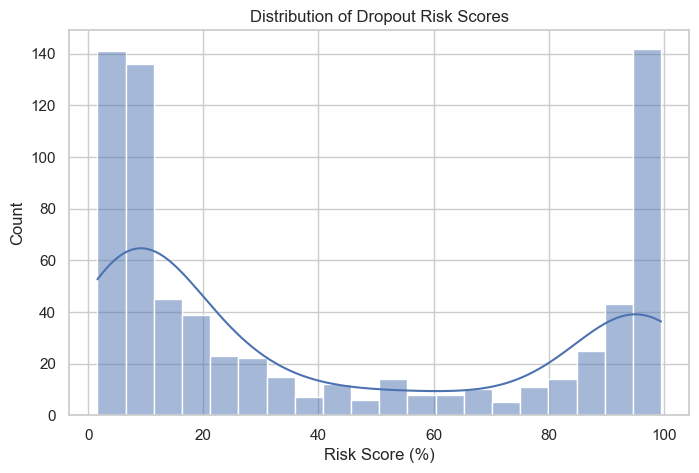

In [31]:
plt.figure(figsize=(8,5))
sns.histplot(results_df["Risk Score (%)"], bins=20, kde=True)

plt.title("Distribution of Dropout Risk Scores")
plt.xlabel("Risk Score (%)")
plt.ylabel("Count")

plt.show()

## 7.2. Risk Score Distribution by Actual Outcome

To better understand how well the risk score separates the two groups, the score distributions are compared for students who actually dropped out and students who actually graduated.

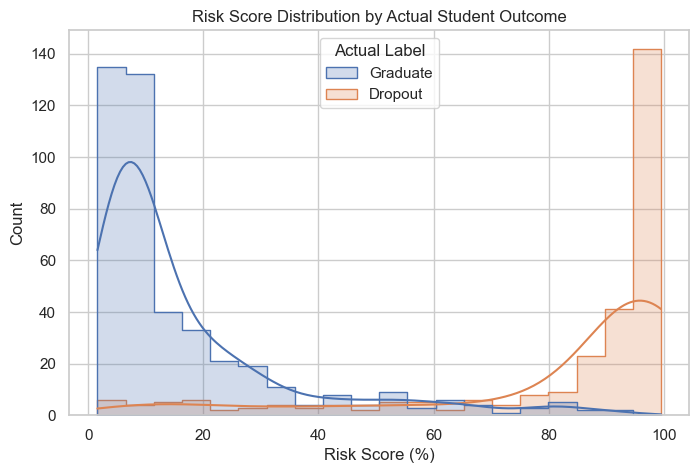

In [32]:
plt.figure(figsize=(8,5))
sns.histplot(
  data=results_df,
  x="Risk Score (%)",
  hue="Actual Label",
  bins=20,
  kde=True,
  element="step"
)

plt.title("Risk Score Distribution by Actual Student Outcome")
plt.xlabel("Risk Score (%)")
plt.ylabel("Count")

plt.show()

## 7.3. Summary Statistics by Actual Outcome

To complement the visual analysis, summary statistics are calculated for the risk scores in each actual outcome group.

In [33]:
results_df.groupby("Actual Label")["Risk Score (%)"].describe()

,count,mean,std,min,25%,50%,75%,max
Actual Label,,,,,,,,
Dropout,284.0,82.271916,26.279219,3.80374,81.181725,94.700357,98.202533,99.518275
Graduate,442.0,16.724653,18.062529,1.60890,5.995514,8.782391,20.123837,92.354946


## 7.4. Average Risk Score by Actual Outcome

The mean risk score for each actual outcome group provides a simple summary of how differently the model scores graduates and dropouts.

In [34]:
avg_risk_by_outcome = results_df.groupby("Actual Label")["Risk Score (%)"].mean()

avg_risk_by_outcome

Actual Label
Dropout     82.271916
Graduate    16.724653
Name: Risk Score (%), dtype: float64

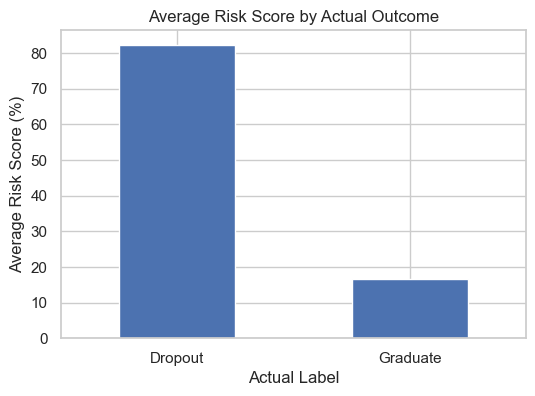

In [35]:
plt.figure(figsize=(6,4))
avg_risk_by_outcome.plot(kind="bar")

plt.title("Average Risk Score by Actual Outcome")
plt.ylabel("Average Risk Score (%)")
plt.xticks(rotation=0)

plt.show()

## 7.5. Interpretation

The distribution analysis shows that the predicted probabilities behave as meaningful dropout-related risk scores. Students who actually dropped out generally receive much higher risk scores, while students who graduated are concentrated more strongly in the low-risk range.

This pattern is also reflected in the summary statistics. The average risk score is approximately **82.3%** for dropout cases and **16.7%** for graduate cases, indicating strong separation between the two groups.

At the same time, some overlap remains between the distributions. This suggests that the risk score should be interpreted as an early warning indicator rather than a certain prediction. Overall, the results support the use of these scores for risk categorization, threshold selection, and early support planning.

# 8. Risk Category Design

The probability-based risk scores become more useful in practice when they are translated into clear and interpretable risk categories. Instead of working only with raw percentages, students can be grouped into broader bands such as low, medium, and high risk.

This makes the results easier to communicate and allows the predictive model to be used more naturally in an early intervention setting. Risk categories can help universities decide which students may only require normal monitoring, which may benefit from additional review, and which may need more immediate support.

## 8.1. Define Risk Categories

To make the risk scores easier to interpret, three risk bands are defined:

  * Low Risk: 0% to below 30%
  * Medium Risk: 30% to below 60%
  * High Risk: 60% and above

These ranges are used as an initial practical framework for grouping students based on their estimated dropout-related risk.

In [38]:
def assign_risk_category(score):
  if score < 30:
    return "Low Risk"
  elif score < 60:
    return "Medium Risk"
  else:
    return "High Risk"

In [39]:
results_df["Risk Category"] = results_df["Risk Score (%)"].apply(assign_risk_category)

results_df.head(10)

,Actual Outcome,Predicted Class,Dropout Probability,Risk Score (%),Actual Label,Predicted Label,Risk Category
0,0,0,0.045605,4.560514,Graduate,Graduate,Low Risk
1,0,0,0.137796,13.779627,Graduate,Graduate,Low Risk
2,1,0,0.304614,30.461360,Dropout,Graduate,Medium Risk
3,0,0,0.262435,26.243459,Graduate,Graduate,Low Risk
4,0,1,0.669212,66.921223,Graduate,Dropout,High Risk
5,0,0,0.043264,4.326397,Graduate,Graduate,Low Risk
6,0,0,0.176661,17.666103,Graduate,Graduate,Low Risk
7,1,1,0.970705,97.070487,Dropout,Dropout,High Risk
8,0,0,0.477843,47.784305,Graduate,Graduate,Medium Risk
9,1,1,0.873673,87.367311,Dropout,Dropout,High Risk


## 8.2. Distribution of Students Across Risk Categories

After defining the categories, the number of students in each risk group can be examined.

In [40]:
risk_category_counts = results_df["Risk Category"].value_counts()

risk_category_counts

Risk Category
Low Risk       401
High Risk      258
Medium Risk     67
Name: count, dtype: int64

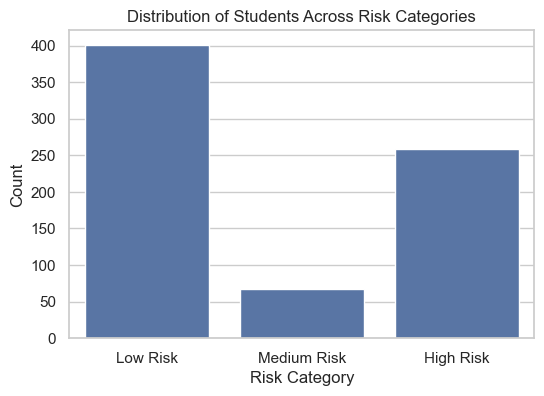

In [42]:
plt.figure(figsize=(6,4))
sns.countplot(x="Risk Category", data=results_df, order=["Low Risk", "Medium Risk", "High Risk"])

plt.title("Distribution of Students Across Risk Categories")
plt.xlabel("Risk Category")
plt.ylabel("Count")

plt.show()

## 8.3. Percentage of Students in Each Risk Category

To better understand the relative size of each group, the **percentage** of students in each category is also calculated.

In [48]:
risk_category_percentages = risk_category_percentages.reindex(["Low Risk", "Medium Risk", "High Risk"])

risk_category_percentages

Risk Category
Low Risk       55.23416
Medium Risk     9.22865
High Risk      35.53719
Name: proportion, dtype: float64

## 8.4. Actual Dropout Rate Within Each Risk Category

A useful way to evaluate whether the categories are meaningful is to examine the actual dropout rate within each group.

If the categories work well, the dropout rate should be:

  * lowest in the low-risk group
  * higher in the medium-risk group
  * highest in the high-risk group

In [45]:
dropout_rate_by_category = results_df.groupby("Risk Category")["Actual Outcome"].mean() * 100

dropout_rate_by_category = dropout_rate_by_category.reindex(["Low Risk", "Medium Risk", "High Risk"])
dropout_rate_by_category

Risk Category
Low Risk        6.234414
Medium Risk    35.820896
High Risk      91.085271
Name: Actual Outcome, dtype: float64

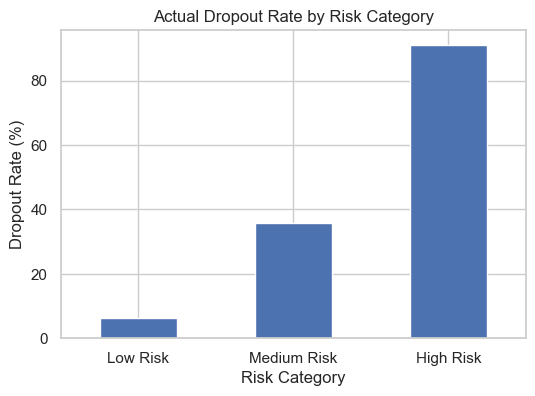

In [46]:
plt.figure(figsize=(6,4))
dropout_rate_by_category.plot(kind="bar")

plt.title("Actual Dropout Rate by Risk Category")
plt.xlabel("Risk Category")
plt.ylabel("Dropout Rate (%)")
plt.xticks(rotation=0)

plt.show()

## 8.5. Crosstab of Risk Category and Actual Outcome

To see the relationship more directly, a crosstab can also be created.

In [47]:
pd.crosstab(results_df["Risk Category"], results_df["Actual Label"])

Actual Label,Dropout,Graduate
Risk Category,,
High Risk,235,23
Low Risk,25,376
Medium Risk,24,43


## 8.6 Interpretation

The risk category analysis shows that the percentage-based scores can be translated into meaningful and practical student groups. The three categories correspond to clearly different levels of observed dropout risk.

The `Low Risk` group has a dropout rate of only **6.2%**, while the `Medium Risk` group rises to **35.8%**. The `High Risk` group has a dropout rate of **91.1%**, showing that students in this category are very strongly associated with historical dropout patterns.

Overall, these results suggest that the selected risk bands provide a useful framework for communicating model output and supporting different levels of monitoring, review, and early intervention.

# 9. Threshold Analysis

Although the risk categories provide a useful practical framework, institutions may also need a more explicit decision rule for when to take action. In classification models, this is determined by the decision threshold, which defines the probability level above which a student is classified as being at risk.

By default, a threshold of **0.5** is used. However, this may not be the most suitable choice in an early intervention context, where missing a truly at-risk student may be more costly than incorrectly flagging a student who would eventually graduate.

This section evaluates how different thresholds affect model performance, with particular attention to the trade-off between precision and recall.

## 9.1. Evaluate Multiple Thresholds

Several threshold values are tested to examine how performance changes across different decision rules.

In [51]:
thresholds_to_test = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]

threshold_results = []

for t in thresholds_to_test:
  y_pred_t = (y_probs >= t).astype(int)

  threshold_results.append({
    "Threshold": t,
    "Accuracy": accuracy_score(y_test, y_pred_t),
    "Precision": precision_score(y_test, y_pred_t),
    "Recall": recall_score(y_test, y_pred_t),
    "F1 Score": f1_score(y_test, y_pred_t)
  })

threshold_df = pd.DataFrame(threshold_results)
threshold_df

,Threshold,Accuracy,Precision,Recall,F1 Score
0,0.2,0.820937,0.704787,0.933099,0.803030
1,0.3,0.874656,0.796923,0.911972,0.850575
2,0.4,0.888430,0.837209,0.887324,0.861538
3,0.5,0.896694,0.871886,0.862676,0.867257
4,0.6,0.900826,0.910853,0.827465,0.867159
5,0.7,0.903581,0.945833,0.799296,0.866412
6,0.8,0.892562,0.959821,0.757042,0.846457


## 9.2. Visualize Threshold Trade-Offs

The evaluation metrics are plotted to show how threshold selection affects model behavior.

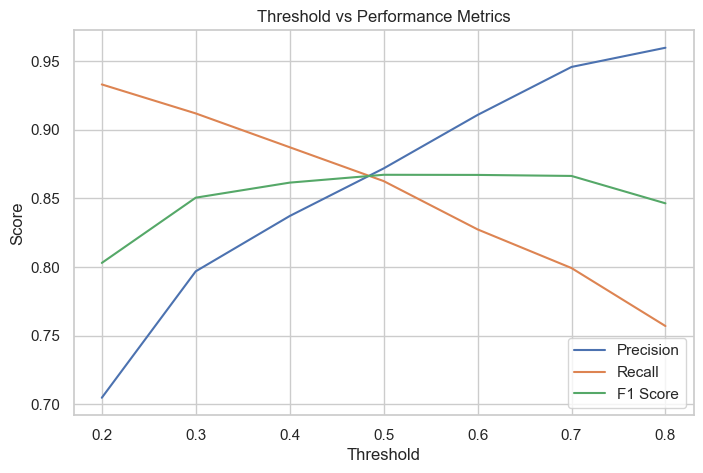

In [52]:
threshold_df.set_index("Threshold")[["Precision", "Recall", "F1 Score"]].plot(figsize=(8,5))

plt.title("Threshold vs Performance Metrics")
plt.ylabel("Score")
plt.xticks(rotation=0)

plt.show()

## 9.3. Compare Number of Students Flagged at Each Threshold

In practice, different thresholds also affect how many students are identified as at risk.

In [53]:
flagged_counts = []

for t in thresholds_to_test:
  y_pred_t = (y_probs >= t).astype(int)
  flagged_counts.append({
    "Threshold": t,
    "Students Flagged": y_pred_t.sum()
  })

flagged_df = pd.DataFrame(flagged_counts)
flagged_df

,Threshold,Students Flagged
0,0.2,376
1,0.3,325
2,0.4,301
3,0.5,281
4,0.6,258
5,0.7,240
6,0.8,224


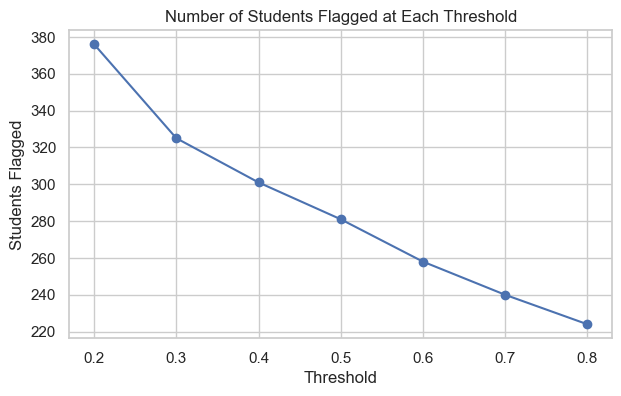

In [54]:
plt.figure(figsize=(7,4))
plt.plot(flagged_df["Threshold"], flagged_df["Students Flagged"], marker="o")

plt.title("Number of Students Flagged at Each Threshold")
plt.xlabel("Threshold")
plt.ylabel("Students Flagged")

plt.show()

## 9.4. Interpretation